# Indicadores post hoc C/IER

Pablo Rogers

In [ ]:
#| label: setup-02
#| include: false

library(tidyverse)
library(careless)
library(gt)
library(patchwork)
library(modi)

In [ ]:
#| label: leitura-nivel-2
#| include: false

dados_importados <- read_csv2(
    "../../Data/IntermediateData/whoqol_imported.csv",
    show_col_types = FALSE
)

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.

## Definição das funções auxiliares

In [ ]:
#| label: funcoes-auxiliares

# --- Laz.R index (Biemann et al., 2025) ---
calc_lazr <- function(x) {
    tr <- table(x[-length(x)], x[-1], useNA = "ifany")
    sum(tr^2 / rowSums(tr)) / (length(x) - 1)
}

# --- Algoritmo Kneedle (Biemann et al., 2025) ---
dist2d <- function(a, b, c) {
    v1 <- b - c
    v2 <- a - b
    m <- cbind(v1, v2)
    det(m) / sqrt(sum(v1 * v1))
}

kneedle <- function(values, sign) {
    start <- c(1, values[1])
    end <- c(length(values), values[length(values)])
    which.max(lapply(seq_along(values), function(idx) {
        sign * -1 * dist2d(c(idx, values[idx]), start, end)
    }))
}

## Cálculo dos quatro indicadores

O IRV e o longstring são calculados através do pacote `careless`. O Laz.R é calculado através da função `calc_lazr` e o MD é calculado através do pacote `modi` e da função `MDmiss` para dar conta dos valores omissos.

In [ ]:
#| label: calculo-indicadores

lazr_vals <- apply(itens, 1, calc_lazr)

longstr_vals <- longstring(itens)

md_vals <- as.numeric(MDmiss(
    data = as.matrix(itens),
    center = colMeans(itens, na.rm = TRUE),
    cov = cov(itens, use = "pairwise.complete.obs")
))

irv_vals <- irv(itens, split = FALSE)

## Variáveis individuais

In [ ]:
#| label: tibble-indicadores

df_indicadores <- tibble(
    ID      = id_col,
    LazR    = round(lazr_vals, 3),
    Longstr = as.integer(longstr_vals),
    MD      = round(md_vals, 3),
    IRV     = round(irv_vals, 3)
)

df_indicadores

# A tibble: 1,298 × 5
            ID  LazR Longstr    MD   IRV
         <dbl> <dbl>   <int> <dbl> <dbl>
 1 10441016017 0.388       3 49.5  1.47 
 2 10440981694 0.493       5 13.5  0.662
 3 10440601239 0.493       6 79.1  1.47 
 4 10440562981 0.569       9 27.4  1.29 
 5 10440358563 0.454       8 32.3  1.48 
 6 10440199369 0.647      10  6.94 0.945
 7 10438952564 0.444       6 39.9  0.951
 8 10438951127 0.382       3 24.2  1.06 
 9 10438633244 0.41        3 41.7  0.857
10 10438605204 0.479       5 12.2  1.09 
# ℹ 1,288 more rows

## Visualização univariada

### Laz.R

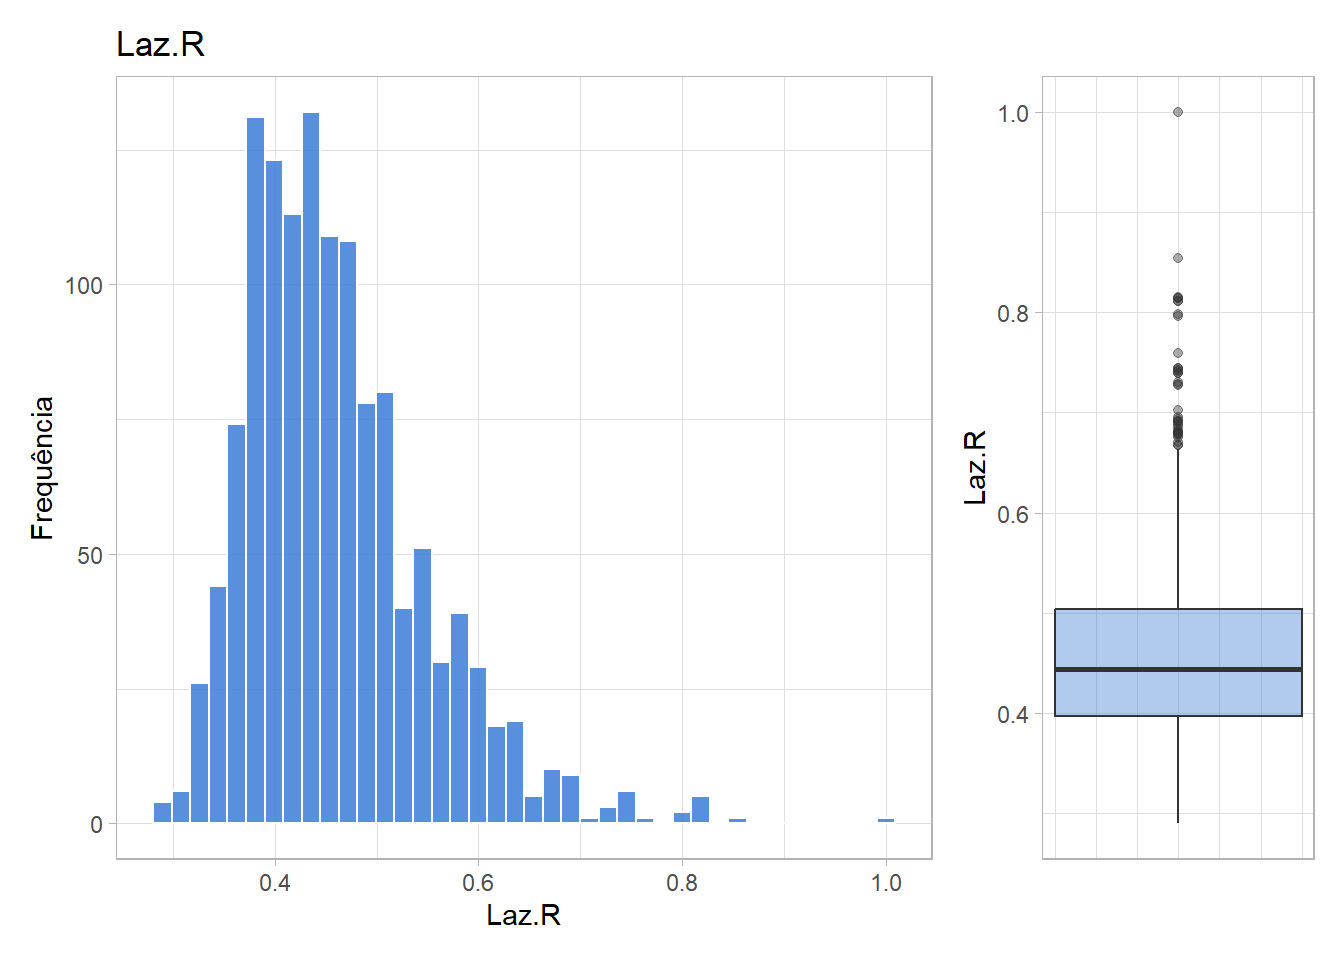

In [ ]:
#| label: viz-lazr

p_hist_lazr <- ggplot(df_indicadores, aes(x = LazR)) +
    geom_histogram(bins = 40, fill = "#3B7DD8", color = "white", alpha = 0.85) +
    labs(title = "Laz.R", x = "Laz.R", y = "Frequência") +
    theme_light()

p_box_lazr <- ggplot(df_indicadores, aes(y = LazR)) +
    geom_boxplot(fill = "#3B7DD8", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Laz.R") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

p_hist_lazr + p_box_lazr + plot_layout(widths = c(3, 1))

### Longstring

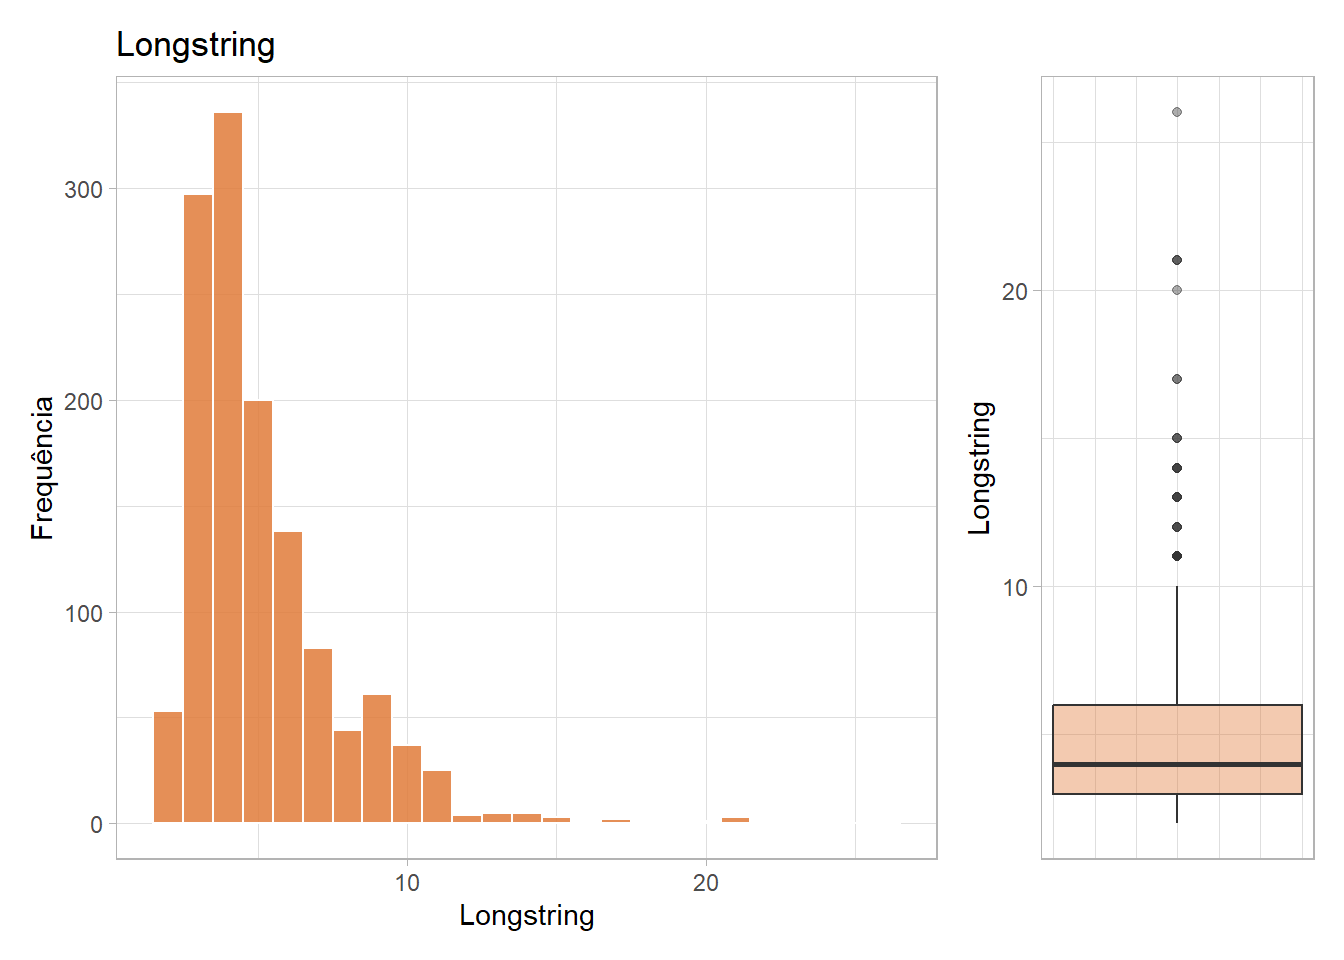

In [ ]:
#| label: viz-longstr

p_hist_ls <- ggplot(df_indicadores, aes(x = Longstr)) +
    geom_histogram(binwidth = 1, fill = "#E07B39", color = "white", alpha = 0.85) +
    labs(title = "Longstring", x = "Longstring", y = "Frequência") +
    theme_light()

p_box_ls <- ggplot(df_indicadores, aes(y = Longstr)) +
    geom_boxplot(fill = "#E07B39", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "Longstring") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

p_hist_ls + p_box_ls + plot_layout(widths = c(3, 1))

### Mahalanobis Distance

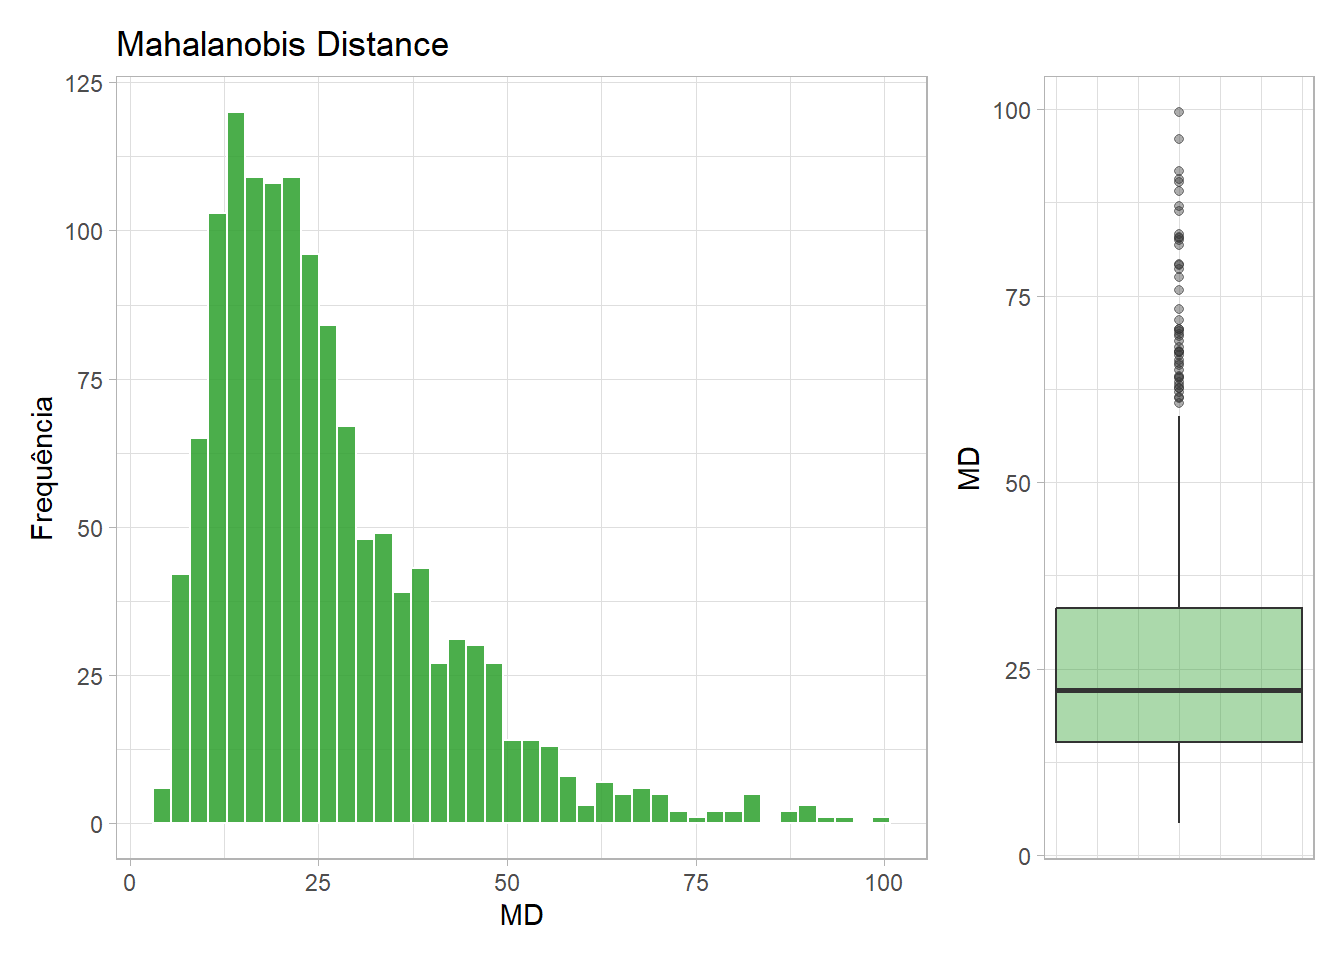

In [ ]:
#| label: viz-md

p_hist_md <- ggplot(df_indicadores, aes(x = MD)) +
    geom_histogram(bins = 40, fill = "#2CA02C", color = "white", alpha = 0.85) +
    labs(title = "Mahalanobis Distance", x = "MD", y = "Frequência") +
    theme_light()

p_box_md <- ggplot(df_indicadores, aes(y = MD)) +
    geom_boxplot(fill = "#2CA02C", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "MD") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

p_hist_md + p_box_md + plot_layout(widths = c(3, 1))

### IRV

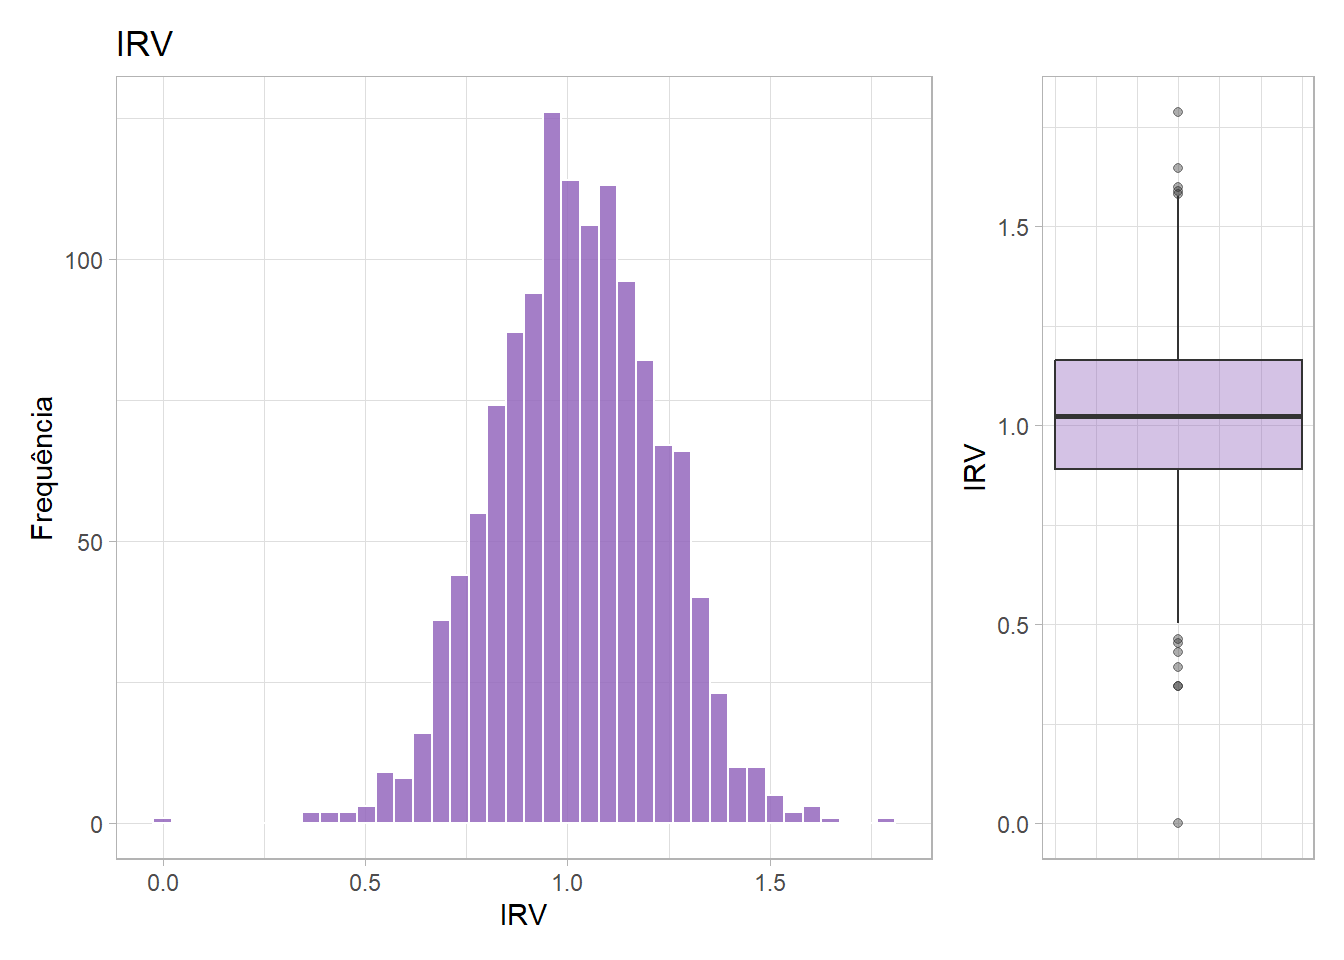

In [ ]:
#| label: viz-irv

p_hist_irv <- ggplot(df_indicadores, aes(x = IRV)) +
    geom_histogram(bins = 40, fill = "#9467BD", color = "white", alpha = 0.85) +
    labs(title = "IRV", x = "IRV", y = "Frequência") +
    theme_light()

p_box_irv <- ggplot(df_indicadores, aes(y = IRV)) +
    geom_boxplot(fill = "#9467BD", alpha = 0.4, width = 0.3) +
    labs(title = NULL, y = "IRV") +
    theme_light() +
    theme(
        axis.title.x = element_blank(), axis.text.x = element_blank(),
        axis.ticks.x = element_blank()
    )

p_hist_irv + p_box_irv + plot_layout(widths = c(3, 1))

## Pontos de corte via algoritmo Kneedle

In [ ]:
#| label: kneedle-cutoffs

calc_kneedle <- function(x, sign_val) {
    x_sorted <- sort(x, decreasing = TRUE, na.last = NA)
    n <- length(x_sorted)
    if (n == 0 || sum(x_sorted, na.rm = TRUE) == 0) {
        return(list(pct = NA_real_, crit = NA_real_, sorted = x_sorted))
    }
    pos <- kneedle(x_sorted, sign_val)
    pct <- pos / n
    crit <- quantile(x_sorted, probs = 1 - pct, na.rm = TRUE, names = FALSE)
    list(pct = pct, crit = crit, sorted = x_sorted)
}

kn_lazr <- calc_kneedle(df_indicadores$LazR, -1)
kn_longstr <- calc_kneedle(df_indicadores$Longstr, -1)
kn_md <- calc_kneedle(df_indicadores$MD, -1)
kn_irv_high <- calc_kneedle(df_indicadores$IRV, -1)
kn_irv_low <- calc_kneedle(df_indicadores$IRV, +1)

tab_cutoffs <- tibble(
    Indicador = c(
        "Laz.R", "Longstring", "MD",
        "IRV (high end)", "IRV (low end)"
    ),
    `Valor crítico` = round(c(
        kn_lazr$crit, kn_longstr$crit, kn_md$crit,
        kn_irv_high$crit, kn_irv_low$crit
    ), 2),
    `% suspeitos` = round(c(
        kn_lazr$pct, kn_longstr$pct, kn_md$pct,
        kn_irv_high$pct, 1 - kn_irv_low$pct
    ) * 100, 1)
)

tab_cutoffs |>
    knitr::kable(
        caption = "Pontos de corte — Algoritmo Kneedle (Biemann et al., 2025)",
        digits  = c(0, 2, 1)
    )

  Indicador          Valor crítico   \% suspeitos
  ---------------- --------------- --------------
  Laz.R                       0.60            6.8
  Longstring                  7.00           14.8
  MD                         40.17           15.4
  IRV (high end)              1.34            4.9
  IRV (low end)               0.69            3.8

  : Pontos de corte --- Algoritmo Kneedle (Biemann et al., 2025)


## Gráficos com pontos de corte

### Laz.R

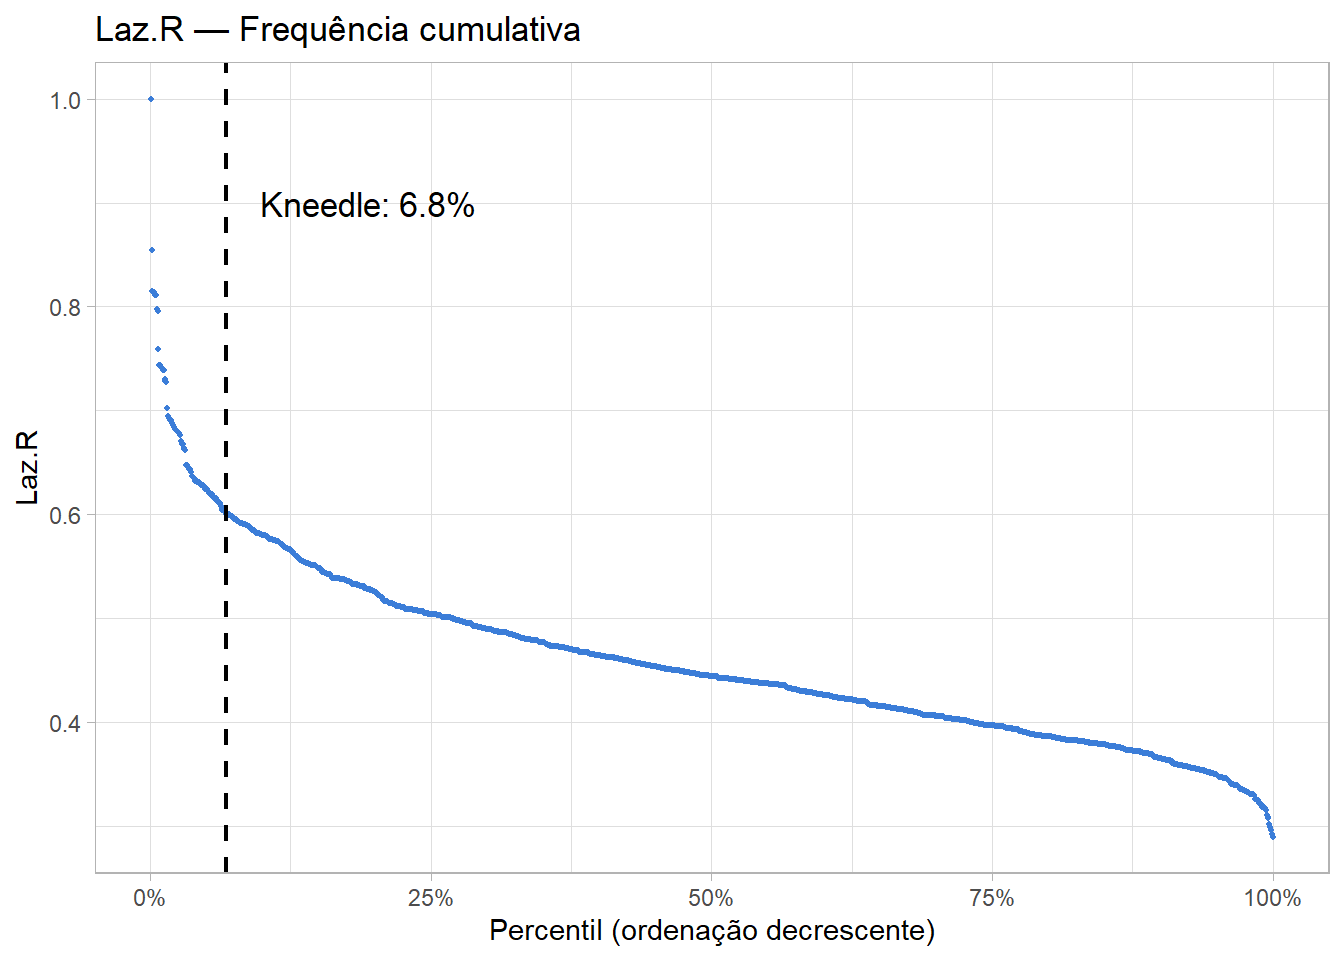

In [ ]:
#| label: cum-lazr

# Monta o data frame para a curva cumulativa (ordenação decrescente)
make_cum_df <- function(sorted_vals) {
    n <- length(sorted_vals)
    tibble(Index_value = sorted_vals, percent = seq_len(n) / n)
}

cum_lazr <- make_cum_df(kn_lazr$sorted)

ggplot(cum_lazr, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#3B7DD8") +
    geom_vline(xintercept = kn_lazr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_lazr$pct + 0.03, y = max(cum_lazr$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_lazr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Laz.R — Frequência cumulativa",
        x = "Percentil (ordenação decrescente)", y = "Laz.R"
    ) +
    theme_light()

### Longstring

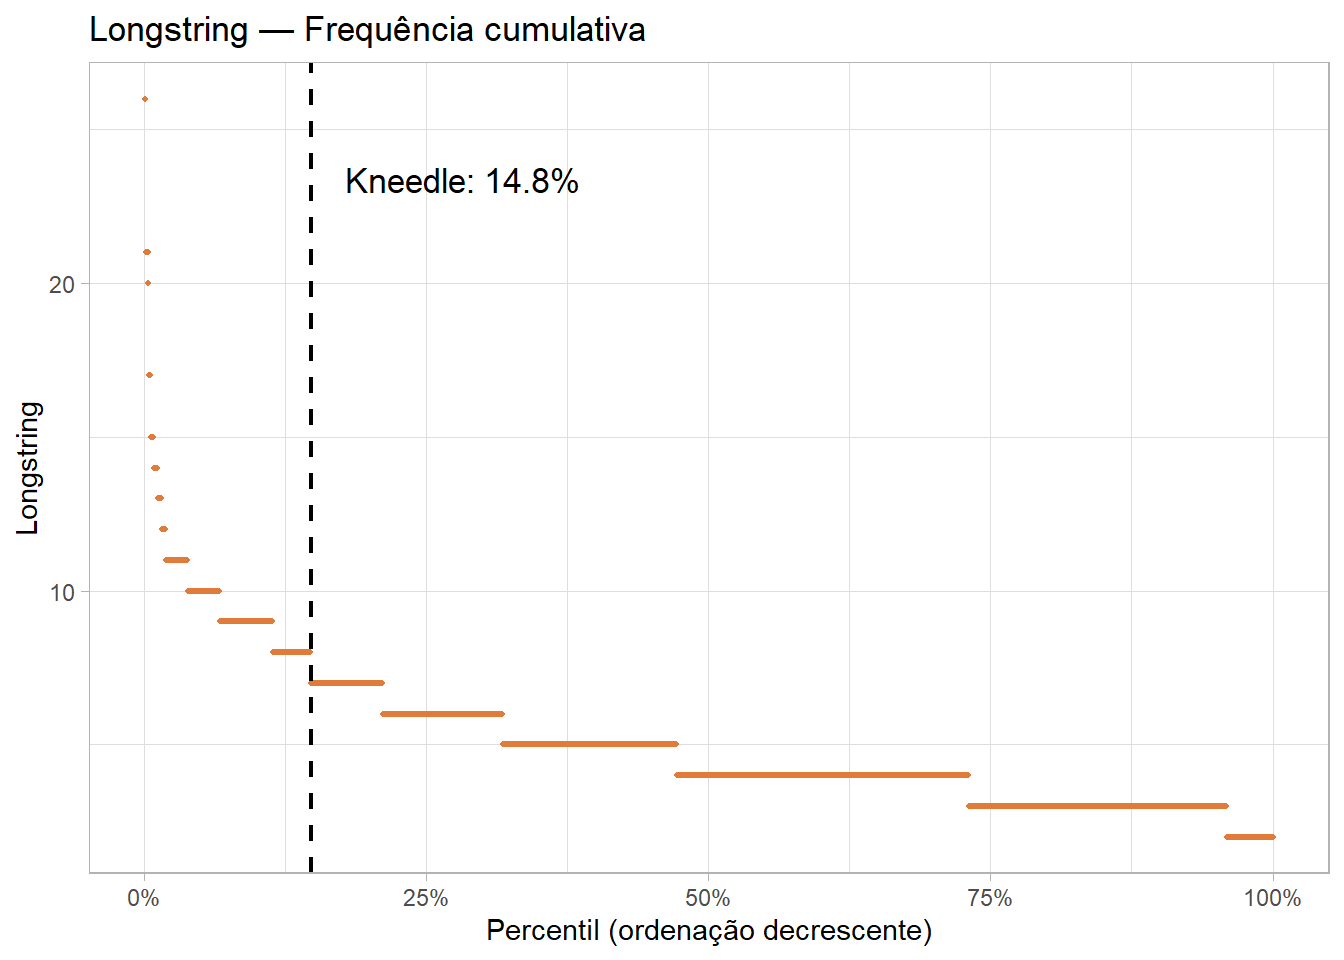

In [ ]:
#| label: cum-longstr

cum_ls <- make_cum_df(kn_longstr$sorted)

ggplot(cum_ls, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#E07B39") +
    geom_vline(xintercept = kn_longstr$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_longstr$pct + 0.03, y = max(cum_ls$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_longstr$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Longstring — Frequência cumulativa",
        x = "Percentil (ordenação decrescente)", y = "Longstring"
    ) +
    theme_light()

### Mahalanobis Distance

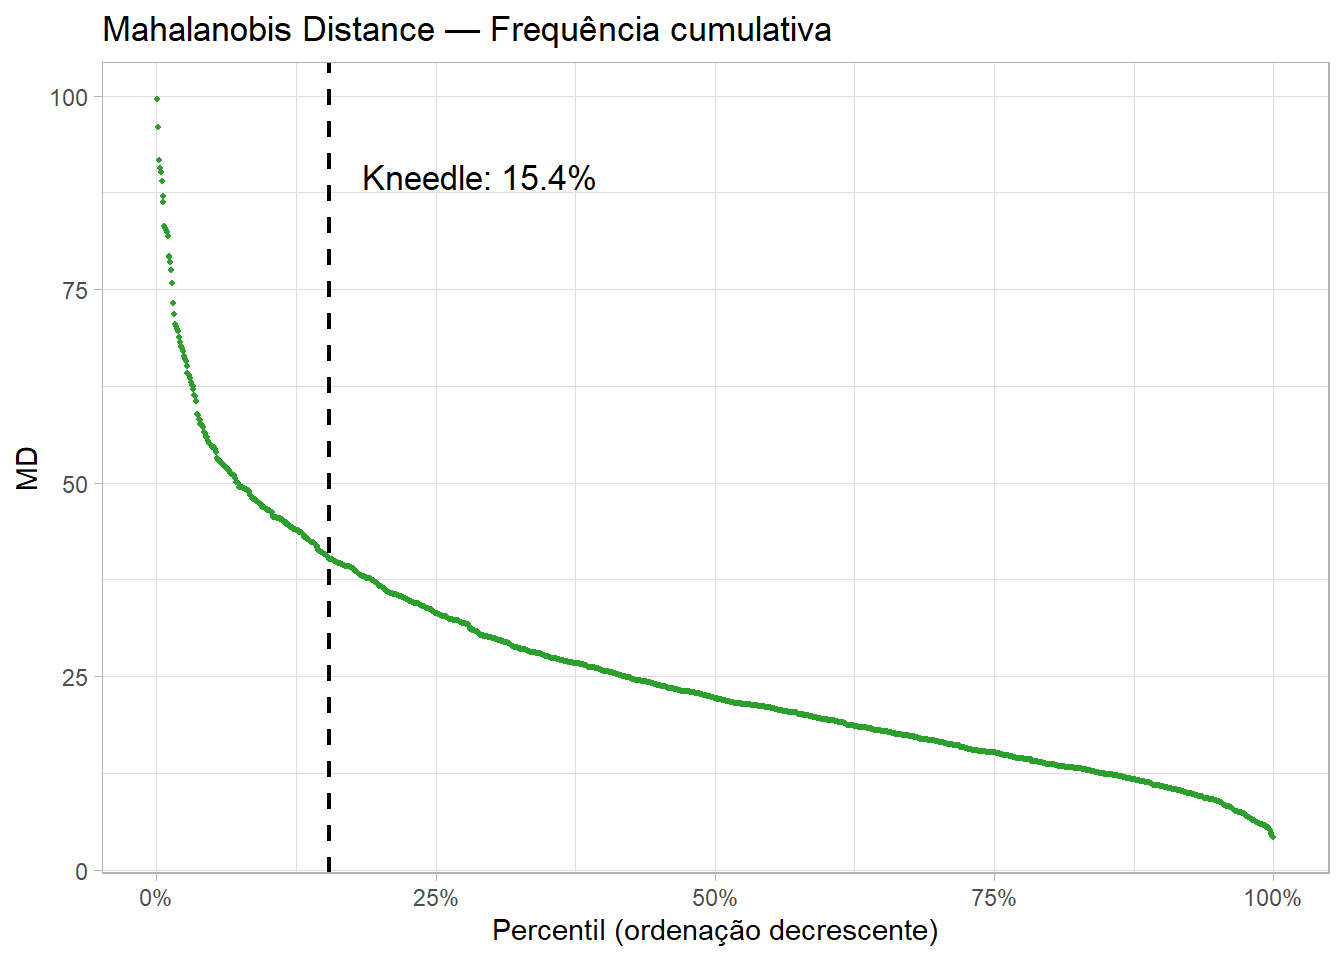

In [ ]:
#| label: cum-md

cum_md <- make_cum_df(kn_md$sorted)

ggplot(cum_md, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#2CA02C") +
    geom_vline(xintercept = kn_md$pct, linetype = "dashed", linewidth = 0.8) +
    annotate("text",
        x = kn_md$pct + 0.03, y = max(cum_md$Index_value, na.rm = TRUE) * 0.9,
        label = paste0("Kneedle: ", round(kn_md$pct * 100, 1), "%"),
        hjust = 0, size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "Mahalanobis Distance — Frequência cumulativa",
        x = "Percentil (ordenação decrescente)", y = "MD"
    ) +
    theme_light()

### IRV

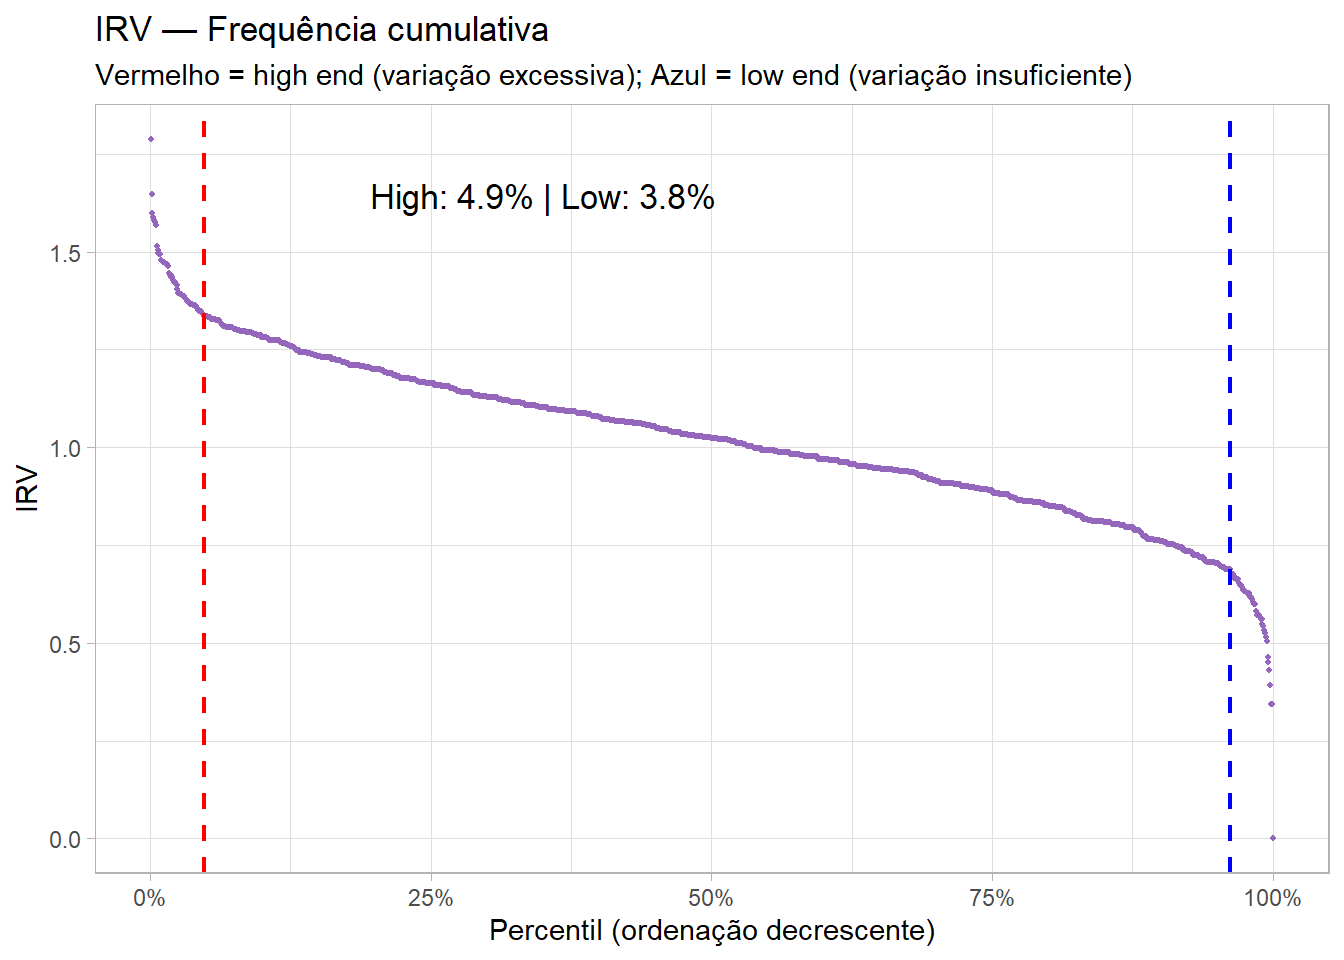

In [ ]:
#| label: cum-irv

cum_irv <- make_cum_df(kn_irv_high$sorted)

ggplot(cum_irv, aes(x = percent, y = Index_value)) +
    geom_point(size = 0.8, color = "#9467BD") +
    geom_vline(
        xintercept = kn_irv_high$pct, linetype = "dashed", linewidth = 0.8,
        color = "red"
    ) +
    geom_vline(
        xintercept = kn_irv_low$pct, linetype = "dashed", linewidth = 0.8,
        color = "blue"
    ) +
    annotate("text",
        x = 0.35, y = max(cum_irv$Index_value, na.rm = TRUE) * 0.92,
        label = paste0(
            "High: ", round(kn_irv_high$pct * 100, 1),
            "% | Low: ", round((1 - kn_irv_low$pct) * 100, 1), "%"
        ),
        size = 4.5
    ) +
    scale_x_continuous(labels = scales::percent) +
    labs(
        title = "IRV — Frequência cumulativa",
        subtitle = "Vermelho = high end (variação excessiva); Azul = low end (variação insuficiente)",
        x = "Percentil (ordenação decrescente)", y = "IRV"
    ) +
    theme_light()

## Flags de C/IER

In [ ]:
#| label: flags

df_flags <- df_indicadores |>
    mutate(
        LazR_FLAG     = if_else(LazR >= kn_lazr$crit, 1L, 0L),
        Longstr_FLAG  = if_else(Longstr > kn_longstr$crit, 1L, 0L),
        MD_FLAG       = if_else(MD >= kn_md$crit, 1L, 0L),
        IRV_high_FLAG = if_else(IRV >= kn_irv_high$crit, 1L, 0L),
        IRV_low_FLAG  = if_else(IRV <= kn_irv_low$crit, 1L, 0L)
    )

df_flags

# A tibble: 1,298 × 10
            ID  LazR Longstr    MD   IRV LazR_FLAG Longstr_FLAG MD_FLAG
         <dbl> <dbl>   <int> <dbl> <dbl>     <int>        <int>   <int>
 1 10441016017 0.388       3 49.5  1.47          0            0       1
 2 10440981694 0.493       5 13.5  0.662         0            0       0
 3 10440601239 0.493       6 79.1  1.47          0            0       1
 4 10440562981 0.569       9 27.4  1.29          0            1       0
 5 10440358563 0.454       8 32.3  1.48          0            1       0
 6 10440199369 0.647      10  6.94 0.945         1            1       0
 7 10438952564 0.444       6 39.9  0.951         0            0       0
 8 10438951127 0.382       3 24.2  1.06          0            0       0
 9 10438633244 0.41        3 41.7  0.857         0            0       1
10 10438605204 0.479       5 12.2  1.09          0            0       0
# ℹ 1,288 more rows
# ℹ 2 more variables: IRV_high_FLAG <int>, IRV_low_FLAG <int>

### Resumo das flags

In [ ]:
#| label: resumo-flags

df_flags |>
    summarise(
        across(ends_with("_FLAG"), list(
            n_suspeitos   = \(x) sum(x, na.rm = TRUE),
            pct_suspeitos = \(x) round(mean(x, na.rm = TRUE) * 100, 1)
        ))
    ) |>
    pivot_longer(everything(),
        names_to = c("Indicador", ".value"),
        names_pattern = "(.+)_(n_suspeitos|pct_suspeitos)"
    ) |>
    knitr::kable(
        caption = "Resumo de respondentes sinalizados como C/IER",
        col.names = c("Indicador", "N suspeitos", "% suspeitos")
    )

  Indicador         N suspeitos   \% suspeitos
  --------------- ------------- --------------
  LazR_FLAG                  91            7.0
  Longstr_FLAG              191           14.7
  MD_FLAG                   200           15.4
  IRV_high_FLAG              66            5.1
  IRV_low_FLAG               49            3.8

  : Resumo de respondentes sinalizados como C/IER


In [ ]:
#| label: exportacao-flags
#| include: false

dados_screened <- dados_importados |>
    select(ID, Q1:Q26) |>
    left_join(df_flags, by = "ID")

write_csv2(dados_screened, "../../Data/IntermediateData/whoqol_screened.csv")